# Import all needed packages

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd


# Upload our NRI data and seperate out our states

In [109]:
all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")
ohio_tracts = all_tracts[all_tracts["STATE"]=="Ohio"]
ohio_tracts
ohio_tracts.to_csv("state_tracts1.csv")

In [110]:
all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")
missouri_tracts = all_tracts[all_tracts["STATE"]=="Missouri"]
missouri_tracts
missouri_tracts.to_csv("state_tracts2.csv")

# Load in each CSV

In [111]:
oh_nri = pd.read_csv("state_tracts1.csv")
oh_svi = pd.read_csv("Ohio.csv")
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

In [112]:
mo_nri = pd.read_csv("state_tracts2.csv")
mo_svi = pd.read_csv("Missouri.csv")
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

# Combine our data (NRI and SVI)

In [113]:
oh_nri['STCNTY'] = oh_nri['STCOFIPS']
oh_nri.columns

oh_complete_data = pd.merge(oh_nri, oh_svi, on = 'STCNTY', suffixes=('', '_right'))

oh_complete_data.columns

Index(['Unnamed: 0', 'OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS',
       'COUNTY', 'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=626)

In [114]:
mo_nri['STCNTY'] = mo_nri['STCOFIPS']
mo_nri.columns

mo_complete_data = pd.merge(mo_nri, mo_svi, on = 'STCNTY', suffixes=('', '_right'))

mo_complete_data.columns

Index(['Unnamed: 0', 'OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS',
       'COUNTY', 'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=626)

# Look for missing values

In [115]:
oh_complete_data.isna()

,Unnamed: 0,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478179,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
478180,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
478181,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
478182,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [116]:
mo_complete_data.isna()

,Unnamed: 0,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148013,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
148014,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
148015,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
148016,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# Replace any missing data 

In [117]:
oh_complete_data_filled = oh_complete_data.fillna(oh_complete_data.mean(numeric_only = True))

print(oh_complete_data_filled)

        Unnamed: 0   OID_        NRI_ID STATE STATEABBRV  STATEFIPS   COUNTY  \
0            56919  57799  T39001770100  Ohio         OH         39    Adams   
1            56919  57799  T39001770100  Ohio         OH         39    Adams   
2            56919  57799  T39001770100  Ohio         OH         39    Adams   
3            56919  57799  T39001770100  Ohio         OH         39    Adams   
4            56919  57799  T39001770100  Ohio         OH         39    Adams   
...            ...    ...           ...   ...        ...        ...      ...   
478179       60080  60960  T39175938500  Ohio         OH         39  Wyandot   
478180       60080  60960  T39175938500  Ohio         OH         39  Wyandot   
478181       60080  60960  T39175938500  Ohio         OH         39  Wyandot   
478182       60080  60960  T39175938500  Ohio         OH         39  Wyandot   
478183       60080  60960  T39175938500  Ohio         OH         39  Wyandot   

       COUNTYTYPE  COUNTYFIPS  STCOFIPS

In [118]:
mo_complete_data_filled = mo_complete_data.fillna(mo_complete_data.mean(numeric_only = True))

print(mo_complete_data_filled)

        Unnamed: 0   OID_        NRI_ID     STATE STATEABBRV  STATEFIPS  \
0            42201  43081  T29001950100  Missouri         MO         29   
1            42201  43081  T29001950100  Missouri         MO         29   
2            42201  43081  T29001950100  Missouri         MO         29   
3            42201  43081  T29001950100  Missouri         MO         29   
4            42201  43081  T29001950100  Missouri         MO         29   
...            ...    ...           ...       ...        ...        ...   
148013       43854  44734  T29510127800  Missouri         MO         29   
148014       43854  44734  T29510127800  Missouri         MO         29   
148015       43854  44734  T29510127800  Missouri         MO         29   
148016       43854  44734  T29510127800  Missouri         MO         29   
148017       43854  44734  T29510127800  Missouri         MO         29   

           COUNTY COUNTYTYPE  COUNTYFIPS  STCOFIPS  ...  EP_ASIAN  MP_ASIAN  \
0           Adair   

# Risks for our states

In [119]:
#tornado: building and population risk  
oh_complete_data['tornado_building_risk'] = oh_complete_data['TRND_AFREQ']*oh_complete_data['TRND_EXPB']
oh_complete_data['tornado_population_risk'] = oh_complete_data['TRND_AFREQ']*oh_complete_data['TRND_EXPP']

#landslide: building and population risk  
oh_complete_data['landslide_building_risk'] = oh_complete_data['LNDS_AFREQ']*oh_complete_data['LNDS_EXPB']
oh_complete_data['landslide_population_risk'] = oh_complete_data['LNDS_AFREQ']*oh_complete_data['LNDS_EXPP']

print(oh_complete_data)


        Unnamed: 0   OID_        NRI_ID STATE STATEABBRV  STATEFIPS   COUNTY  \
0            56919  57799  T39001770100  Ohio         OH         39    Adams   
1            56919  57799  T39001770100  Ohio         OH         39    Adams   
2            56919  57799  T39001770100  Ohio         OH         39    Adams   
3            56919  57799  T39001770100  Ohio         OH         39    Adams   
4            56919  57799  T39001770100  Ohio         OH         39    Adams   
...            ...    ...           ...   ...        ...        ...      ...   
478179       60080  60960  T39175938500  Ohio         OH         39  Wyandot   
478180       60080  60960  T39175938500  Ohio         OH         39  Wyandot   
478181       60080  60960  T39175938500  Ohio         OH         39  Wyandot   
478182       60080  60960  T39175938500  Ohio         OH         39  Wyandot   
478183       60080  60960  T39175938500  Ohio         OH         39  Wyandot   

       COUNTYTYPE  COUNTYFIPS  STCOFIPS

In [120]:
#tornado: building and population risk  
mo_complete_data['tornado_building_risk'] = mo_complete_data['TRND_AFREQ']*mo_complete_data['TRND_EXPB']
mo_complete_data['tornado_population_risk'] = mo_complete_data['TRND_AFREQ']*mo_complete_data['TRND_EXPP']

#landslide: building and population risk  
mo_complete_data['landslide_building_risk'] = mo_complete_data['LNDS_AFREQ']*mo_complete_data['LNDS_EXPB']
mo_complete_data['landslide_population_risk'] = mo_complete_data['LNDS_AFREQ']*mo_complete_data['LNDS_EXPP']

print(mo_complete_data)

        Unnamed: 0   OID_        NRI_ID     STATE STATEABBRV  STATEFIPS  \
0            42201  43081  T29001950100  Missouri         MO         29   
1            42201  43081  T29001950100  Missouri         MO         29   
2            42201  43081  T29001950100  Missouri         MO         29   
3            42201  43081  T29001950100  Missouri         MO         29   
4            42201  43081  T29001950100  Missouri         MO         29   
...            ...    ...           ...       ...        ...        ...   
148013       43854  44734  T29510127800  Missouri         MO         29   
148014       43854  44734  T29510127800  Missouri         MO         29   
148015       43854  44734  T29510127800  Missouri         MO         29   
148016       43854  44734  T29510127800  Missouri         MO         29   
148017       43854  44734  T29510127800  Missouri         MO         29   

           COUNTY COUNTYTYPE  COUNTYFIPS  STCOFIPS  ...  EP_NHPI  MP_NHPI  \
0           Adair     

# Let's group by counties and display summary tables

In [121]:
### Group your data by county
oh_grouped_data = oh_complete_data.groupby('COUNTY',as_index=False)

## Run summary mean by county
oh_grouped_data = oh_complete_data.groupby('COUNTY').agg(mean_tornado=('tornado_building_risk', 'mean'), 
                                                   mean_lnds=('landslide_building_risk', 'mean'))

print(oh_grouped_data)

            mean_tornado     mean_lnds
COUNTY                                
Adams       4.803490e+07  1.494992e+07
Allen       6.011639e+06  4.133393e+03
Ashland     2.725016e+07  9.230940e+05
Ashtabula   7.107267e+06  1.793413e+04
Athens      6.882501e+06  7.640087e+06
...                  ...           ...
Washington  5.283620e+06  6.419270e+06
Wayne       7.405746e+06  7.587548e+04
Williams    2.806782e+07  5.458925e+04
Wood        1.312481e+07  1.034172e+04
Wyandot     3.481488e+07  6.716037e+04

[88 rows x 2 columns]


In [122]:
### Group your data by county
mo_grouped_data = mo_complete_data.groupby('COUNTY',as_index=False)

## Run summary mean by county
mo_grouped_data = mo_complete_data.groupby('COUNTY').agg(mean_tornado=('tornado_building_risk', 'mean'), 
                                                   mean_lnds=('landslide_building_risk', 'mean'))

print(mo_grouped_data)

            mean_tornado     mean_lnds
COUNTY                                
Adair       2.336913e+07  2.360435e+06
Andrew      5.481255e+07  1.269243e+06
Atchison    1.980965e+08  2.922324e+06
Audrain     6.791083e+07  5.405826e+04
Barry       5.747915e+07  5.307909e+06
...                  ...           ...
Washington  5.444652e+07  2.113210e+07
Wayne       7.261608e+07  3.512098e+07
Webster     4.636225e+07  1.090405e+06
Worth       1.141034e+08  2.305676e+06
Wright      8.928409e+07  5.112138e+06

[114 rows x 2 columns]


# Figures of our data

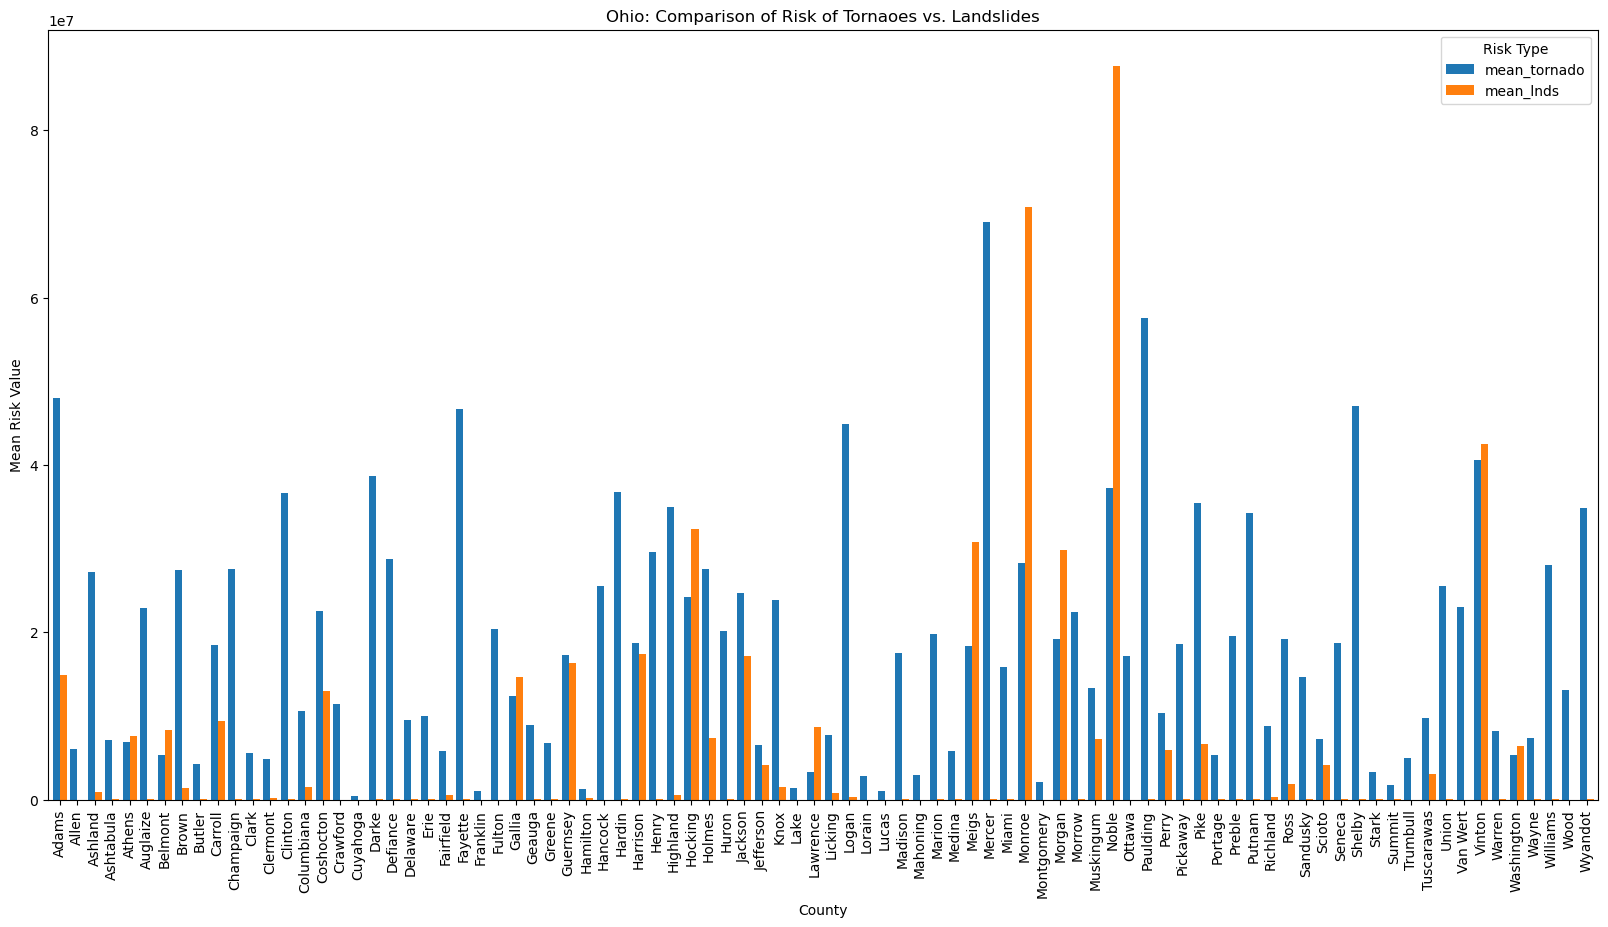

In [123]:
oh_grouped_data.plot(kind='bar', figsize=(20, 10), width=0.8)

# Customizing the plot
plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Ohio: Comparison of Risk of Tornaoes vs. Landslides')
plt.xticks(rotation=90)

# Show the plot
plt.legend(title="Risk Type")  # Adding a legend to distinguish risk types
plt.show()

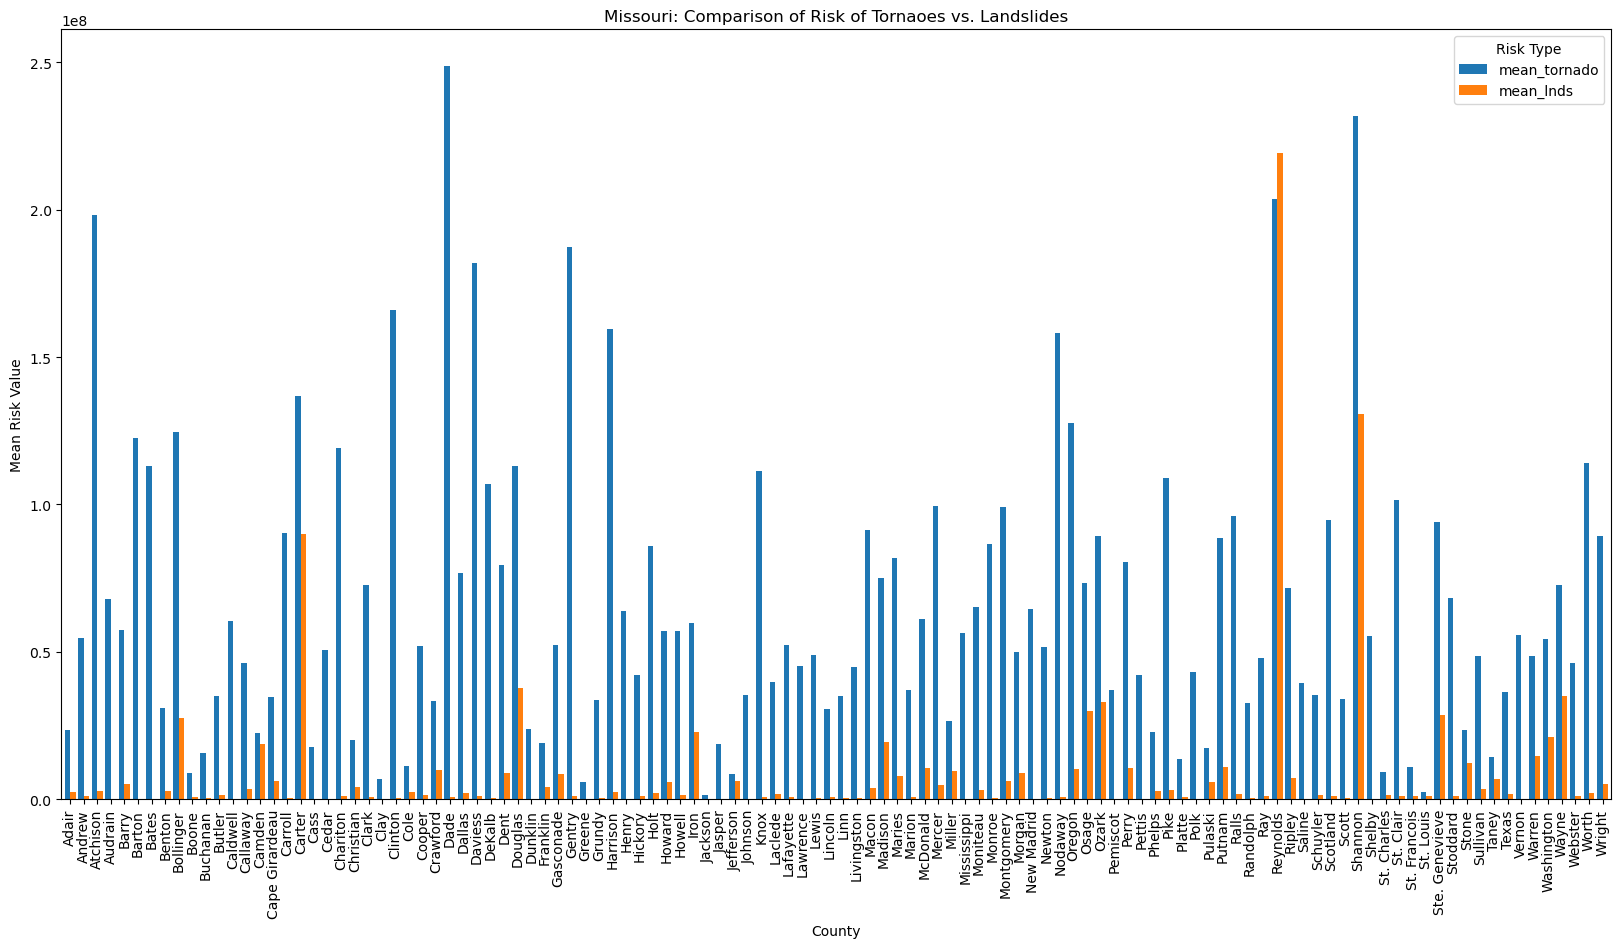

In [124]:
mo_grouped_data.plot(kind='bar', figsize=(20, 10), width=0.8)

# Customizing the plot
plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Missouri: Comparison of Risk of Tornaoes vs. Landslides')
plt.xticks(rotation=90)

# Show the plot
plt.legend(title="Risk Type")  # Adding a legend to distinguish risk types
plt.show()

# Now let's use our method to calculate risk

In [127]:
oh_complete_data['tornado_risk'] = oh_complete_data['TRND_EALT']*oh_complete_data['SOVI_SCORE'] / oh_complete_data['RESL_SCORE']
#print(oh_complete_data)
print(oh_complete_data['tornado_risk'])

0         314353.885115
1         314353.885115
2         314353.885115
3         314353.885115
4         314353.885115
              ...      
478179    149863.568677
478180    149863.568677
478181    149863.568677
478182    149863.568677
478183    149863.568677
Name: tornado_risk, Length: 478184, dtype: float64


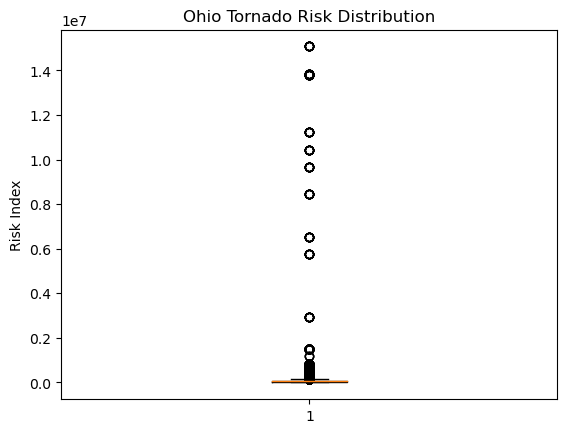

In [128]:
#plot the data
plt.figure
plt.boxplot(oh_complete_data['tornado_risk'])
plt.title("Ohio Tornado Risk Distribution")
plt.ylabel("Risk Index")
plt.show()

In [129]:
oh_complete_data['landslide_risk'] = oh_complete_data['LNDS_EALT']*oh_complete_data['SOVI_SCORE'] / oh_complete_data['RESL_SCORE']
#print(oh_complete_data)
print(oh_complete_data['landslide_risk'])

0         498.364522
1         498.364522
2         498.364522
3         498.364522
4         498.364522
             ...    
478179    125.375525
478180    125.375525
478181    125.375525
478182    125.375525
478183    125.375525
Name: landslide_risk, Length: 478184, dtype: float64


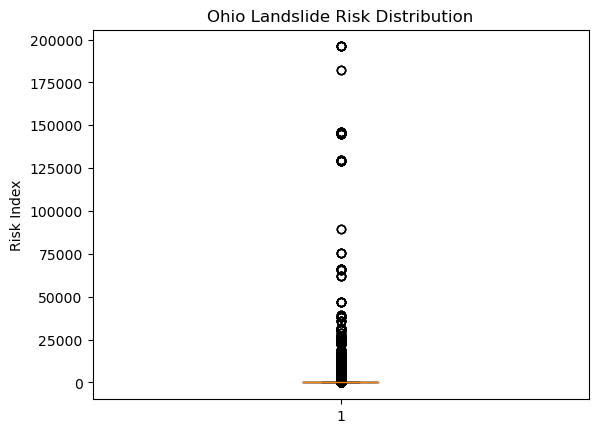

In [130]:
#plot the data
plt.figure
plt.boxplot(oh_complete_data['landslide_risk'])
plt.title("Ohio Landslide Risk Distribution")
plt.ylabel("Risk Index")
plt.show()

In [131]:
mo_complete_data['tornado_risk'] = mo_complete_data['TRND_EALT']*mo_complete_data['SOVI_SCORE'] / mo_complete_data['RESL_SCORE']
#print(mo_complete_data)
print(mo_complete_data['tornado_risk'])

0         433913.148137
1         433913.148137
2         433913.148137
3         433913.148137
4         433913.148137
              ...      
148013    883641.792577
148014    883641.792577
148015    883641.792577
148016    883641.792577
148017    883641.792577
Name: tornado_risk, Length: 148018, dtype: float64


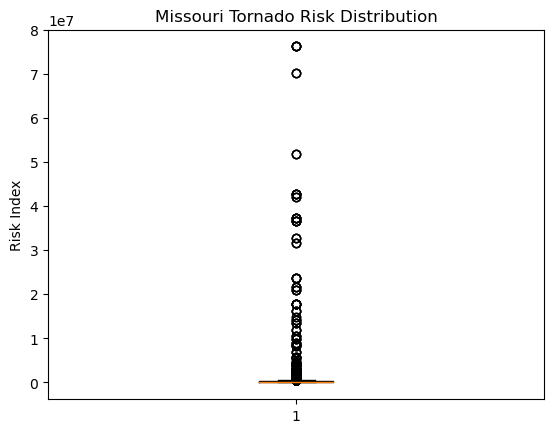

In [132]:
#plot the data
plt.figure
plt.boxplot(mo_complete_data['tornado_risk'])
plt.title("Missouri Tornado Risk Distribution")
plt.ylabel("Risk Index")
plt.show()

In [133]:
mo_complete_data['landslide_risk'] = mo_complete_data['LNDS_EALT']*mo_complete_data['SOVI_SCORE'] / mo_complete_data['RESL_SCORE']
#print(mo_complete_data)
print(mo_complete_data['landslide_risk'])

0         1858.955760
1         1858.955760
2         1858.955760
3         1858.955760
4         1858.955760
             ...     
148013      28.166191
148014      28.166191
148015      28.166191
148016      28.166191
148017      28.166191
Name: landslide_risk, Length: 148018, dtype: float64


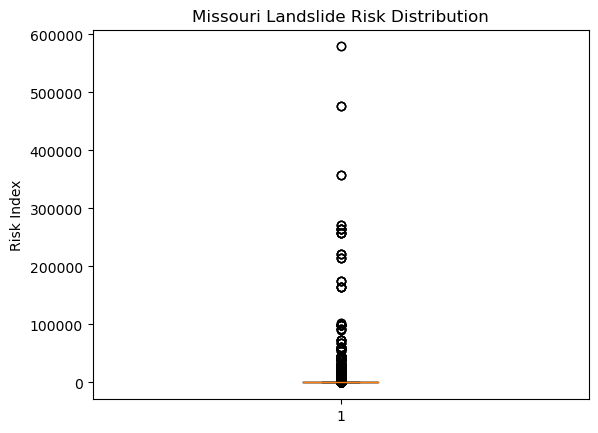

In [134]:
plt.figure
plt.boxplot(mo_complete_data['landslide_risk'])
plt.title("Missouri Landslide Risk Distribution")
plt.ylabel("Risk Index")
plt.show()

# Geopandas

In [135]:
## Read the Census Tracts data

tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')

##Verifications for Shape files

tracts.head()

###This checks for Coordinate Reference System (CRS)

tracts.crs

###Checks the geometries in the data
tracts.geometry.head()

0    POLYGON ((-9626784.493 3827718.774, -9626802.4...
1    POLYGON ((-9625497.973 3827700.43, -9625504.76...
2    POLYGON ((-9623646.617 3823891.992, -9623666.3...
3    POLYGON ((-9622012.001 3826514.039, -9622007.2...
4    POLYGON ((-9619304.709 3823820.353, -9619304.3...
Name: geometry, dtype: geometry

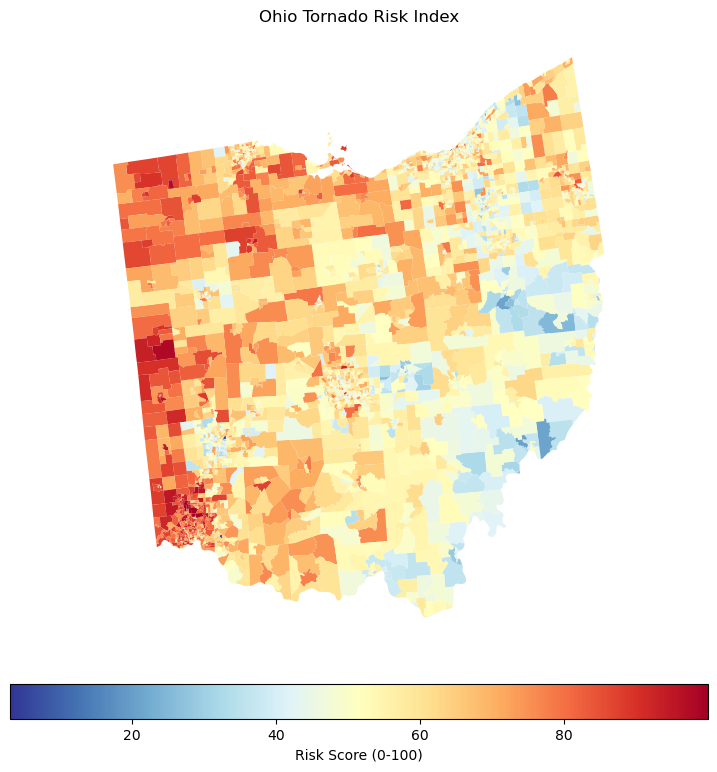

In [136]:
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')

state_map = tracts[tracts["STATE"] == "Ohio"].copy()
state_map = state_map.replace(-9999, np.nan)


state_map = state_map.to_crs("ESRI:102003")

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

state_map.plot(
    column="TRND_RISKS", 
    cmap="RdYlBu_r",
    legend=True,
    ax=ax,
    legend_kwds={"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink":0.6,"pad":0.05},
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Ohio Tornado Risk Index")
ax.set_axis_off()
plt.show()

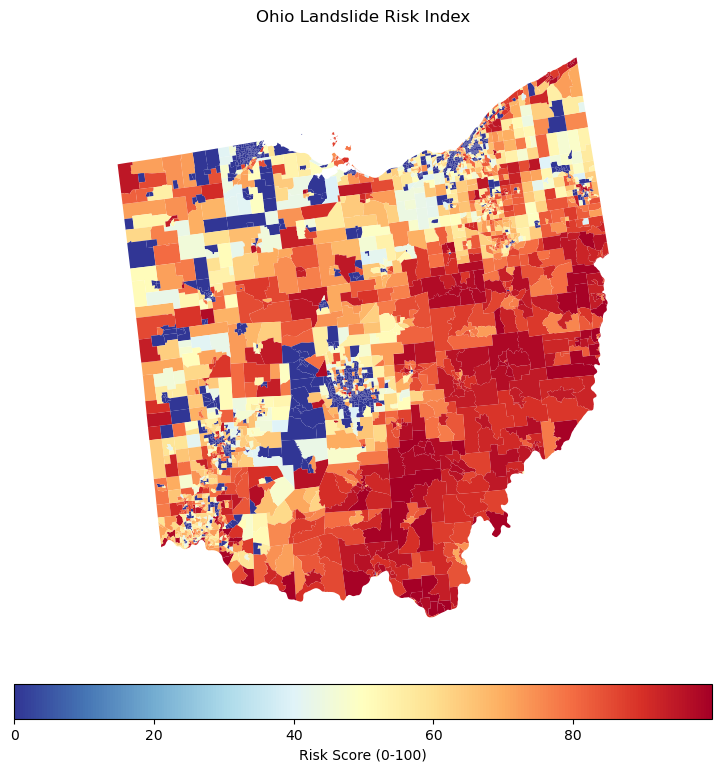

In [137]:
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')

state_map = tracts[tracts["STATE"] == "Ohio"].copy()
state_map = state_map.replace(-9999, np.nan)


state_map = state_map.to_crs("ESRI:102003")

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

state_map.plot(
    column="LNDS_RISKS", 
    cmap="RdYlBu_r",
    legend=True,
    ax=ax,
    legend_kwds={"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink":0.6,"pad":0.05},
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Ohio Landslide Risk Index")
ax.set_axis_off()
plt.show()

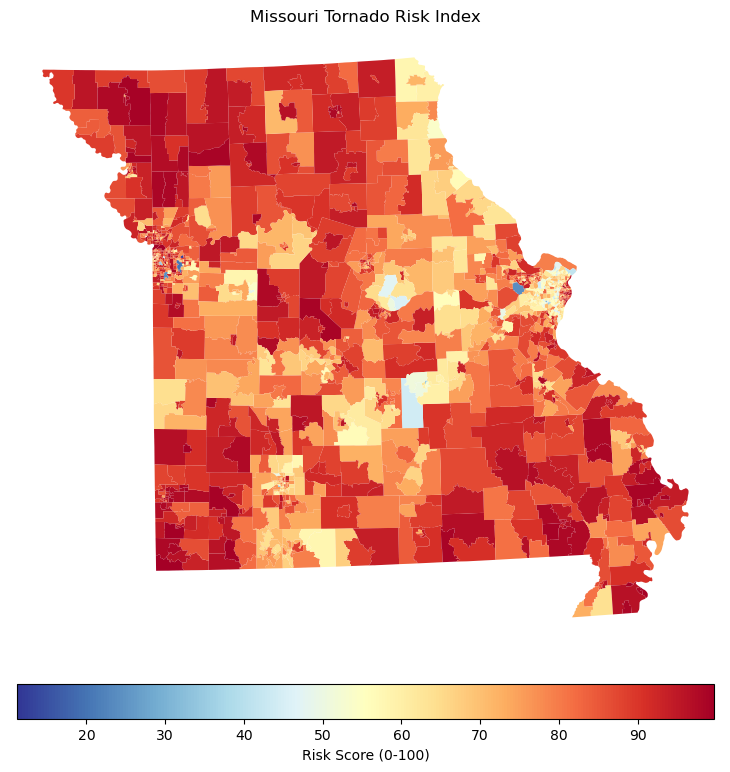

In [138]:
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')

state_map = tracts[tracts["STATE"] == "Missouri"].copy()
state_map = state_map.replace(-9999, np.nan)


state_map = state_map.to_crs("ESRI:102003")

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

state_map.plot(
    column="TRND_RISKS", 
    cmap="RdYlBu_r",
    legend=True,
    ax=ax,
    legend_kwds={"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink":0.6,"pad":0.05},
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Missouri Tornado Risk Index")
ax.set_axis_off()
plt.show()

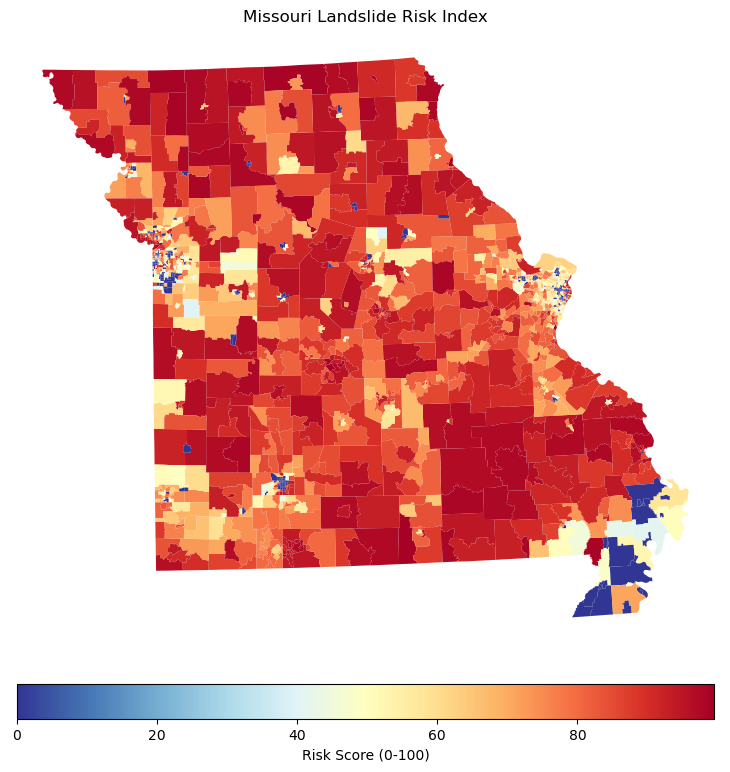

In [139]:
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')

state_map = tracts[tracts["STATE"] == "Missouri"].copy()
state_map = state_map.replace(-9999, np.nan)


state_map = state_map.to_crs("ESRI:102003")

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

state_map.plot(
    column="LNDS_RISKS", 
    cmap="RdYlBu_r",
    legend=True,
    ax=ax,
    legend_kwds={"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink":0.6,"pad":0.05},
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Missouri Landslide Risk Index")
ax.set_axis_off()
plt.show()